In [1]:
import torch
print("Torch Version:", torch.__version__)
import numpy as np
import pandas as pd
from sklearn.decomposition import non_negative_factorization
from collections import defaultdict
import numpy as np
import torch
import tqdm
from sklearn.metrics import roc_auc_score
from sklearn.model_selection import train_test_split
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from torch import Tensor
import torch.nn as nn

Torch Version: 2.6.0+cu124


In [2]:
ratings_df = pd.read_csv("/kaggle/input/personality-2018/personality-isf2018/ratings.csv")
personality_df = pd.read_csv("/kaggle/input/personality-2018/personality-isf2018/personality-data.csv")
movies_df = pd.read_csv('/kaggle/input/movielens-25m/ml-25m/movies.csv')

ratings_df.columns=ratings_df.columns.str.strip()
personality_df.columns=personality_df.columns.str.strip()

ratings_df.rename(columns={'useri':'userId','movie_id':'movieId'},inplace=True)
personality_df.rename(columns={'userid':'userId'},inplace=True)

In [3]:
ratings_df = ratings_df.drop(['tstamp', 'rating'], axis=1)
ratings_df

,userId,movieId
0,8e7cebf9a234c064b75016249f2ac65e,1
1,8e7cebf9a234c064b75016249f2ac65e,2
2,8e7cebf9a234c064b75016249f2ac65e,3
3,8e7cebf9a234c064b75016249f2ac65e,5
4,8e7cebf9a234c064b75016249f2ac65e,6
...,...,...
1028746,721ea658e148fc0f76ddd6e2b0e02422,95167
1028747,721ea658e148fc0f76ddd6e2b0e02422,103335
1028748,721ea658e148fc0f76ddd6e2b0e02422,104374
1028749,721ea658e148fc0f76ddd6e2b0e02422,107890


In [4]:
personality_columns=['openness', 'agreeableness', 'emotional_stability',
       'conscientiousness', 'extraversion']

personality_features=personality_df[['userId']+personality_columns]

filtered_personality = (
    personality_features
    .sort_values(by='userId', ascending=True)
)

# personality_features.drop('mappedUserID',axis=1,inplace=True)

filtered_personality

,userId,openness,agreeableness,emotional_stability,conscientiousness,extraversion
563,005fe8678214011d7f92e51f9a546d40,5.5,6.0,2.0,4.5,1.0
1679,0066fac81b62656f032c085d96e378f4,4.5,4.5,2.5,4.5,4.0
882,00fa91e202f5e48aa34c05d97867fa74,6.5,3.5,3.0,5.0,5.0
1093,011aedbea90fb3b6d1e7a47526b3bee6,5.5,4.0,3.0,1.5,2.5
1076,013325441cd1755b18c58b8007646bb1,6.5,6.5,6.0,7.0,5.0
...,...,...,...,...,...,...
712,feb85d3dbf8878d745c16a431bf6396e,4.5,4.0,6.0,7.0,3.5
1073,fefc161ac0b429fdbf6b56cc04dd4aa6,3.5,4.0,5.0,6.5,4.5
1730,ff14f409ad4f18cfcc72d2478355464d,5.0,4.5,6.0,7.0,4.5
1827,ff8b293ae258fe516c39acecb966dba4,4.5,5.5,7.0,5.5,2.0


In [5]:
user2idx = {u: i for i, u in enumerate(ratings_df['userId'].unique())}
item2idx = {m: i for i, m in enumerate(ratings_df['movieId'].unique())}

ratings_df['userId'] = ratings_df['userId'].map(user2idx)
ratings_df['movieId'] = ratings_df['movieId'].map(item2idx)

num_users = len(user2idx)
num_items = len(item2idx)

# Create positive interactions
interactions = ratings_df[['userId','movieId']].values

# Train/test split
train_pos, test_pos = train_test_split(interactions, test_size=0.2, random_state=42)


ratings_df


,userId,movieId
0,0,0
1,0,1
2,0,2
3,0,3
4,0,4
...,...,...
1028746,1819,5709
1028747,1819,5832
1028748,1819,5849
1028749,1819,32966


In [6]:
# Ensure user mapping matches NCF
personality_df['userId'] = personality_df['userId'].map(user2idx)

# Keep only users present in ratings
personality_df = personality_df.dropna(subset=['userId'])
personality_df['userId'] = personality_df['userId'].astype(int)

# Create personality tensor
personality_tensor = torch.tensor(
    personality_df[personality_columns].values, dtype=torch.float32
)

# Normalize personality scores (optional)
personality_tensor = (personality_tensor - personality_tensor.min(0).values) / \
                     (personality_tensor.max(0).values - personality_tensor.min(0).values)

personality_tensor_rand = torch.rand((num_users, 5), dtype=torch.float32)

In [7]:
def negative_sampling(pos_interactions, num_users, num_items, num_neg=4):
    neg_samples = []
    pos_set = set((u, i) for u, i in pos_interactions)
    for (u, i) in pos_interactions:
        for _ in range(num_neg):
            j = np.random.randint(num_items)
            while (u, j) in pos_set:
                j = np.random.randint(num_items)
            neg_samples.append([u, j])
    return np.array(neg_samples)

train_neg = negative_sampling(train_pos, num_users, num_items)
test_neg = negative_sampling(test_pos, num_users, num_items, num_neg=98)

train_data = np.vstack([np.hstack([train_pos, np.ones((len(train_pos),1))]),
                        np.hstack([train_neg, np.zeros((len(train_neg),1))])])

test_data = np.vstack([np.hstack([test_pos, np.ones((len(test_pos),1))]),
                       np.hstack([test_neg, np.zeros((len(test_neg),1))])])

# Shuffle train data
np.random.shuffle(train_data)

# Shuffle test data
np.random.shuffle(test_data)

In [8]:
print("Train positives:", len(train_pos))
print("Test positives:", len(test_pos))
print("Train negatives:", train_neg.shape[0])
print("Test negatives:", test_neg.shape[0])


Train positives: 823000
Test positives: 205751
Train negatives: 3292000
Test negatives: 20163598


In [9]:
train_set = set((int(u), int(i)) for u,i in train_pos)
test_set = set((int(u), int(i)) for u,i in test_pos)
print("Overlap train/test:", len(train_set & test_set))


Overlap train/test: 1976


In [10]:
class RecDataset(Dataset):
    def __init__(self, data):
        self.users = torch.LongTensor(data[:,0])
        self.items = torch.LongTensor(data[:,1])
        self.labels = torch.FloatTensor(data[:,2])
    def __len__(self): return len(self.users)
    def __getitem__(self, idx):
        return self.users[idx], self.items[idx], self.labels[idx]

train_loader = DataLoader(RecDataset(train_data), batch_size=512, shuffle=True)
test_loader = DataLoader(RecDataset(test_data), batch_size=512, shuffle=False)


In [11]:
class NCF(nn.Module):
    def __init__(self, num_users, num_items, embed_dim=5, hidden_layers=[64,32,16,8]):
        super().__init__()
        self.user_embed = nn.Embedding(num_users, embed_dim)
        self.item_embed = nn.Embedding(num_items, embed_dim)

        layers = []
        input_size = embed_dim*2
        for h in hidden_layers:
            layers.append(nn.Linear(input_size, h))
            layers.append(nn.ReLU())
            input_size = h
        self.mlp = nn.Sequential(*layers)
        self.out = nn.Linear(input_size, 1)

    def forward(self, user, item):
        u = self.user_embed(user)
        i = self.item_embed(item)
        x = torch.cat([u, i], dim=-1)
        x = self.mlp(x)
        return torch.sigmoid(self.out(x)).squeeze()


In [12]:
class NCF_Personality(nn.Module):
    def __init__(self, num_users, num_items, personality_tensor, 
                 embed_dim=16, hidden_layers=[64,32,16,8]):
        super().__init__()
        self.user_embed = nn.Embedding(num_users, embed_dim)
        self.item_embed = nn.Embedding(num_items, embed_dim)

        # store personality features for all users
        self.register_buffer("personality", personality_tensor)

        layers = []
        input_size = embed_dim*2 + personality_tensor.shape[1]  # concat with 5 OCEAN traits
        for h in hidden_layers:
            layers.append(nn.Linear(input_size, h))
            layers.append(nn.ReLU())
            input_size = h
        self.mlp = nn.Sequential(*layers)
        self.out = nn.Linear(input_size, 1)

    def forward(self, user, item):
        u = self.user_embed(user)
        i = self.item_embed(item)
        p = self.personality[user]   # get personality row for that user
        x = torch.cat([u, i, p], dim=-1)
        x = self.mlp(x)
        return torch.sigmoid(self.out(x)).squeeze()


In [13]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = NCF(num_users, num_items).to(device)
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)
criterion = nn.BCELoss()

for epoch in range(10):  # increase epochs
    model.train()
    total_loss = 0
    for users, items, labels in train_loader:
        users, items, labels = users.to(device), items.to(device), labels.to(device)
        preds = model(users, items)
        loss = criterion(preds, labels)
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        total_loss += loss.item()
    print(f"Epoch {epoch+1}, Loss={total_loss/len(train_loader):.4f}")


Epoch 1, Loss=0.3352
Epoch 2, Loss=0.2547
Epoch 3, Loss=0.2479
Epoch 4, Loss=0.2454
Epoch 5, Loss=0.2438
Epoch 6, Loss=0.2427
Epoch 7, Loss=0.2416
Epoch 8, Loss=0.2408
Epoch 9, Loss=0.2399
Epoch 10, Loss=0.2391


In [14]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model_p = NCF_Personality(num_users, num_items, personality_tensor).to(device)
optimizer = torch.optim.Adam(model_p.parameters(), lr=0.001)
criterion = nn.BCELoss()

for epoch in range(10):
    model_p.train()
    total_loss = 0
    for users, items, labels in train_loader:
        users, items, labels = users.to(device), items.to(device), labels.to(device)
        preds = model_p(users, items)
        loss = criterion(preds, labels)
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        total_loss += loss.item()
    print(f"[Personality NCF] Epoch {epoch+1}, Loss={total_loss/len(train_loader):.4f}")


[Personality NCF] Epoch 1, Loss=0.3158
[Personality NCF] Epoch 2, Loss=0.2489
[Personality NCF] Epoch 3, Loss=0.2442
[Personality NCF] Epoch 4, Loss=0.2421
[Personality NCF] Epoch 7, Loss=0.2380
[Personality NCF] Epoch 8, Loss=0.2366
[Personality NCF] Epoch 9, Loss=0.2350
[Personality NCF] Epoch 10, Loss=0.2333


In [44]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model_p = NCF_Personality(num_users, num_items, personality_tensor_rand).to(device)
optimizer = torch.optim.Adam(model_p.parameters(), lr=0.001)
criterion = nn.BCELoss()

for epoch in range(5):
    model_p.train()
    total_loss = 0
    for users, items, labels in train_loader:
        users, items, labels = users.to(device), items.to(device), labels.to(device)
        preds = model_p(users, items)
        loss = criterion(preds, labels)
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        total_loss += loss.item()
    print(f"[Personality NCF] Epoch {epoch+1}, Loss={total_loss/len(train_loader):.4f}")


[Personality NCF] Epoch 1, Loss=0.4403
[Personality NCF] Epoch 2, Loss=0.3108
[Personality NCF] Epoch 3, Loss=0.2994
[Personality NCF] Epoch 4, Loss=0.2956
[Personality NCF] Epoch 5, Loss=0.2933


In [14]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model_p = NCF_Personality(num_users, num_items, personality_tensor).to(device)
optimizer = torch.optim.Adam(model_p.parameters(), lr=0.001)
criterion = nn.BCELoss()

for epoch in range(10):
    model_p.train()
    total_loss = 0
    for users, items, labels in train_loader:
        users, items, labels = users.to(device), items.to(device), labels.to(device)
        preds = model_p(users, items)
        loss = criterion(preds, labels)
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        total_loss += loss.item()
    print(f"[Personality NCF] Epoch {epoch+1}, Loss={total_loss/len(train_loader):.4f}")


[Personality NCF] Epoch 1, Loss=0.3150
[Personality NCF] Epoch 2, Loss=0.2484
[Personality NCF] Epoch 3, Loss=0.2440
[Personality NCF] Epoch 4, Loss=0.2419
[Personality NCF] Epoch 5, Loss=0.2404
[Personality NCF] Epoch 6, Loss=0.2388
[Personality NCF] Epoch 7, Loss=0.2372
[Personality NCF] Epoch 8, Loss=0.2352
[Personality NCF] Epoch 9, Loss=0.2329
[Personality NCF] Epoch 10, Loss=0.2306


In [12]:
def evaluate_fast(model, test_pos, num_items, K=10, num_neg=100):
    model.eval()
    HR, NDCG = [], []
    with torch.no_grad():
        for (u, i) in test_pos:
            # Sample random negatives
            neg_items = np.random.choice(num_items, size=num_neg, replace=False)
            items = np.concatenate(([i], neg_items))
            
            u_tensor = torch.LongTensor([u] * len(items)).to(device)
            items_tensor = torch.LongTensor(items).to(device)
            
            scores = model(u_tensor, items_tensor).cpu().numpy()
            
            # rank
            rank = scores.argsort()[::-1]
            topK = items[rank[:K]]
            
            if i in topK:
                HR.append(1)
                idx = np.where(topK == i)[0][0]
                NDCG.append(1 / np.log2(idx+2))
            else:
                HR.append(0)
                NDCG.append(0)
    return np.mean(HR), np.mean(NDCG)
    
# hr3, ndcg3 = evaluate_fast(model, test_pos, num_items, K=3)
# print(f"[Personality NCF] HR@3={hr3:.4f}, NDCG@3={ndcg3:.4f}")
# hr5, ndcg5 = evaluate_fast(model, test_pos, num_items, K=5)
# print(f"[Personality NCF] HR@5={hr5:.4f}, NDCG@5={ndcg5:.4f}")

In [20]:
hr, ndcg = evaluate_fast(model_p, test_pos, num_items, K=5)
print(f"[Personality NCF] HR@5={hr:.4f}, NDCG@5={ndcg:.4f}")

[Personality NCF] HR@5=0.5689, NDCG@5=0.3940


In [45]:
hr, ndcg = evaluate_fast(model_p, test_pos, num_items, K=5)
print(f"[Personality NCF random] HR@5={hr:.4f}, NDCG@5={ndcg:.4f}")

[Personality NCF random] HR@5=0.5691, NDCG@5=0.3944


In [15]:
hr, ndcg = evaluate_fast(model_p, test_pos, num_items, K=5)
print(f"[Personality NCF but with neg_ratio as 4] HR@5={hr:.4f}, NDCG@5={ndcg:.4f}")

[Personality NCF but with neg_ratio as 4] HR@5=0.5829, NDCG@5=0.4030


In [6]:
# Create a mapping from unique user indices to range [0, num_user_nodes):
unique_user_id = ratings_df['userId'].unique()
unique_user_id = pd.DataFrame(data={
    'userId': unique_user_id,
    'mappedUserID': pd.RangeIndex(len(unique_user_id)),
})
print("Mapping of user IDs to consecutive values:")
print("==========================================")
print(unique_user_id.head())
print()
# Create a mapping from unique movie indices to range [0, num_movie_nodes):
unique_movie_id = ratings_df['movieId'].unique()
unique_movie_id = pd.DataFrame(data={
    'movieId': unique_movie_id,
    'mappedMovieID': pd.RangeIndex(len(unique_movie_id)),
})
print("Mapping of movie IDs to consecutive values:")
print("===========================================")
print(unique_movie_id.head())
# Perform merge to obtain the edges from users and movies:
ratings_user_id = pd.merge(ratings_df['userId'], unique_user_id,
                            left_on='userId', right_on='userId', how='left')
ratings_user_id = torch.from_numpy(ratings_user_id['mappedUserID'].values)
ratings_movie_id = pd.merge(ratings_df['movieId'], unique_movie_id,
                            left_on='movieId', right_on='movieId', how='left')
ratings_movie_id = torch.from_numpy(ratings_movie_id['mappedMovieID'].values)
# With this, we are ready to construct our `edge_index` in COO format
# following PyG semantics:
edge_index_user_to_movie = torch.stack([ratings_user_id, ratings_movie_id], dim=0)

print()
print("Final edge indices pointing from users to movies:")
print("=================================================")
print(edge_index_user_to_movie)


Mapping of user IDs to consecutive values:
                             userId  mappedUserID
0  8e7cebf9a234c064b75016249f2ac65e             0
1  77c7d756a093150d4377720abeaeef76             1
2  b7e8a92987a530cc368719a0e60e26a3             2
3  92561f21446e017dd6b68b94b23ad5b7             3
4  030001ac2145a938b07e686a35a2d638             4

Mapping of movie IDs to consecutive values:
   movieId  mappedMovieID
0        1              0
1        2              1
2        3              2
3        5              3
4        6              4

Final edge indices pointing from users to movies:
tensor([[    0,     0,     0,  ...,  1819,  1819,  1819],
        [    0,     1,     2,  ...,  5849, 32966,  6829]])


In [7]:
ratings_df = ratings_df.merge(unique_user_id, on='userId', how='left')
ratings_df = ratings_df.merge(unique_movie_id, on='movieId', how='left')
ratings_df = ratings_df.merge(movies_df[['genres', 'movieId']], on='movieId', how='left')


In [8]:
personality_df = personality_df.merge(unique_user_id, on='userId', how='left')

personality_columns=['openness', 'agreeableness', 'emotional_stability',
       'conscientiousness', 'extraversion']

personality_features=personality_df[['mappedUserID']+personality_columns]

filtered_personality = personality_features[personality_features.index.isin(ratings_df['mappedUserID'])]

filtered_personality = (
    personality_features[personality_features.index.isin(ratings_df['mappedUserID'])]
    .sort_values(by='mappedUserID', ascending=True)
)

# personality_features.drop('mappedUserID',axis=1,inplace=True)

filtered_personality

,mappedUserID,openness,agreeableness,emotional_stability,conscientiousness,extraversion
0,0,5.0,2.0,3.0,2.5,6.5
1,1,7.0,4.0,6.0,5.5,4.0
2,2,4.0,3.0,4.5,2.0,2.5
3,3,5.5,5.5,4.0,4.5,4.0
4,4,5.5,5.5,3.5,4.5,2.5
...,...,...,...,...,...,...
1815,1801,5.5,4.5,3.5,4.5,4.5
1816,1802,4.0,3.0,5.0,5.0,4.0
1817,1803,5.0,5.5,4.0,3.0,4.5
1818,1804,4.0,6.0,3.0,5.0,1.5


In [9]:
shuffled_personality = filtered_personality.copy()

# Shuffle all trait columns as a block
shuffled_traits = (
    shuffled_personality[personality_columns]
    .sample(frac=1, random_state=42)
    .reset_index(drop=True)
)

# Keep mappedUserID order, but assign new random traits
shuffled_personality[personality_columns] = shuffled_traits
shuffled_personality

,mappedUserID,openness,agreeableness,emotional_stability,conscientiousness,extraversion
0,0,7.0,6.0,6.0,5.0,4.0
1,1,4.5,2.5,4.5,2.5,2.0
2,2,5.0,5.5,7.0,7.0,1.5
3,3,7.0,7.0,4.5,4.0,3.0
4,4,5.5,3.5,4.0,4.5,3.0
...,...,...,...,...,...,...
1815,1801,7.0,4.0,3.5,4.0,2.5
1816,1802,6.0,5.0,7.0,4.5,3.5
1817,1803,3.0,2.0,4.5,5.5,1.5
1818,1804,7.0,4.0,3.0,2.0,4.0


In [10]:
num_users = 1820

user_ids = np.arange(num_users)

data = {
    "mappedUserID": user_ids,
    "openness": np.round(np.random.uniform(1, 10, num_users), 1),
    "agreeableness": np.round(np.random.uniform(1, 10, num_users), 1),
    "emotional_stability": np.round(np.random.uniform(1, 10, num_users), 1),
    "conscientiousness": np.round(np.random.uniform(1, 10, num_users), 1),
    "extraversion": np.round(np.random.uniform(1, 10, num_users), 1),
}

df1 = pd.DataFrame(data)
df1.head()

,mappedUserID,openness,agreeableness,emotional_stability,conscientiousness,extraversion
0,0,5.9,7.0,6.7,8.3,7.9
1,1,7.8,1.4,3.2,1.7,4.8
2,2,5.1,2.3,8.6,1.6,2.1
3,3,1.1,2.9,2.5,1.7,5.8
4,4,6.8,7.0,8.1,2.9,9.7


In [12]:
num_users = 1820
user_ids = np.arange(num_users)

mean, std = 5.5, 2.0  

def bounded_normal(size, mean=5.5, std=2.0, low=1, high=10):
    vals = np.random.normal(mean, std, size)
    return np.clip(np.round(vals, 1), low, high)  
    
data1 = {
    "mappedUserID": user_ids,
    "openness": bounded_normal(num_users),
    "agreeableness": bounded_normal(num_users),
    "emotional_stability": bounded_normal(num_users),
    "conscientiousness": bounded_normal(num_users),
    "extraversion": bounded_normal(num_users),
}

df2 = pd.DataFrame(data1)
df2.head()


,mappedUserID,openness,agreeableness,emotional_stability,conscientiousness,extraversion
0,0,4.7,6.9,6.7,10.0,6.3
1,1,3.3,4.6,3.0,5.6,6.9
2,2,4.7,6.2,8.2,8.8,5.5
3,3,5.6,8.0,5.8,4.9,6.7
4,4,6.6,5.5,3.6,9.6,7.9


In [28]:
data = HeteroData()

# Save node indices:
data["user"].node_id = torch.arange(len(unique_user_id))
data["movie"].node_id = torch.arange(len(unique_movie_id))

# Add the node features and edge indices:
#data["movie"].x = torch.tensor(H.T, dtype=torch.float32)
data['user'].x = torch.tensor(df2.drop('mappedUserID',axis=1).values, dtype=torch.float32)
data["user", "rates", "movie"].edge_index = edge_index_user_to_movie

# We also need to make sure to add the reverse edges from movies to users
# in order to let a GNN be able to pass messages in both directions.
# We can leverage the `T.ToUndirected()` transform for this from PyG:
data = T.ToUndirected()(data)

In [29]:
# For this, we first split the set of edges into
# training (80%), validation (10%), and testing edges (10%).
# Across the training edges, we use 70% of edges for message passing,
# and 30% of edges for supervision.
# We further want to generate fixed negative edges for evaluation with a ratio of 2:1.
# Negative edges during training will be generated on-the-fly.
# We can leverage the `RandomLinkSplit()` transform for this from PyG:
transform = T.RandomLinkSplit(
    num_val=0.1,
    num_test=0.1,
    disjoint_train_ratio=0.3,
    neg_sampling_ratio=2.0,
    add_negative_train_samples=False,
    edge_types=("user", "rates", "movie"),
    rev_edge_types=("movie", "rev_rates", "user"), 
)
train_data, val_data, test_data = transform(data)

In [30]:
# In the first hop, we sample at most 20 neighbors.
# In the second hop, we sample at most 10 neighbors.
# In addition, during training, we want to sample negative edges on-the-fly with
# a ratio of 2:1.
# We can make use of the `loader.LinkNeighborLoader` from PyG:

# Define train seed edges:
edge_label_index = train_data["user", "rates", "movie"].edge_label_index
edge_label = train_data["user", "rates", "movie"].edge_label
train_loader = LinkNeighborLoader(
    data=train_data,
    num_neighbors=[20, 10],
    neg_sampling_ratio=2.0,
    edge_label_index=(("user", "rates", "movie"), edge_label_index),
    edge_label=edge_label,
    batch_size=128,
    shuffle=True,
)

# Define the validation seed edges:
edge_label_index = val_data["user", "rates", "movie"].edge_label_index
edge_label = val_data["user", "rates", "movie"].edge_label
val_loader = LinkNeighborLoader(
    data=val_data,
    num_neighbors=[20, 10],
    edge_label_index=(("user", "rates", "movie"), edge_label_index),
    edge_label=edge_label,
    batch_size=3 * 128,
    shuffle=False,
)

# Define the test seed edges:
edge_label_index = test_data["user", "rates", "movie"].edge_label_index
edge_label = test_data["user", "rates", "movie"].edge_label
test_loader = LinkNeighborLoader(
    data=test_data,
    num_neighbors=[20, 10],
    edge_label_index=(("user", "rates", "movie"), edge_label_index),
    edge_label=edge_label,
    batch_size=3 * 128,
    shuffle=False,
)

In [46]:
import torch
import torch.nn.functional as F
from torch_geometric.nn import SAGEConv, to_hetero

# -----------------------------
# GNN backbone
# -----------------------------
class GNN(torch.nn.Module):
    def __init__(self, hidden_channels):
        super().__init__()
        self.conv1 = SAGEConv(hidden_channels, hidden_channels)
        self.conv2 = SAGEConv(hidden_channels, hidden_channels)

    def forward(self, x, edge_index):
        x = F.relu(self.conv1(x, edge_index))
        x = self.conv2(x, edge_index)
        return x

# -----------------------------
# Link prediction classifier
# -----------------------------
class Classifier(torch.nn.Module):
    def forward(self, x_user, x_movie, edge_label_index):
        edge_feat_user = x_user[edge_label_index[0]]
        edge_feat_movie = x_movie[edge_label_index[1]]
        return (edge_feat_user * edge_feat_movie).sum(dim=-1)

# -----------------------------
# Personality predictor (classification now)
# -----------------------------
class PersonalityPredictor(torch.nn.Module):
    def __init__(self, in_channels, out_channels=5):
        super().__init__()
        self.lin1 = torch.nn.Linear(in_channels, in_channels)
        self.lin2 = torch.nn.Linear(in_channels, out_channels)  # logits for 5 classes

    def forward(self, x_user):
        x = F.relu(self.lin1(x_user))
        x = self.lin2(x)  
        return x  # logits

# -----------------------------
# Full model
# -----------------------------
class Model(torch.nn.Module):
    def __init__(self, hidden_channels):
        super().__init__()
        self.user_lin = torch.nn.Linear(5, hidden_channels)
        self.user_emb = torch.nn.Embedding(data["user"].num_nodes, hidden_channels)
        self.movie_emb = torch.nn.Embedding(data["movie"].num_nodes, hidden_channels)

        self.gnn = GNN(hidden_channels)
        self.gnn = to_hetero(self.gnn, metadata=data.metadata())

        self.classifier = Classifier()
        self.personality_predictor = PersonalityPredictor(hidden_channels, out_channels=5)

    def forward(self, data):
        x_dict = {
          "user": self.user_emb(data["user"].node_id) + self.user_lin(data["user"].x),
          "movie": self.movie_emb(data["movie"].node_id),
        }
        final_x_dict = self.gnn(x_dict, data.edge_index_dict)

        pred_link = self.classifier(
            final_x_dict["user"],
            final_x_dict["movie"],
            data["user", "rates", "movie"].edge_label_index,
        )

        pred_personality = self.personality_predictor(final_x_dict["user"])  # logits
        return {"link": pred_link, "personality": pred_personality}


In [47]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model = Model(hidden_channels=5).to(device)
optimizer = torch.optim.Adam(model.parameters(), lr=0.01)

personality_loss_weight = 0.5

for epoch in range(1, 6):
    total_loss = total_link_loss = total_personality_loss = 0
    total_examples = 0

    for sampled_data in tqdm.tqdm(train_loader):
        optimizer.zero_grad()
        sampled_data.to(device)

        pred_dict = model(sampled_data)
        pred_link = pred_dict["link"]
        pred_personality_logits = pred_dict["personality"]

        # --- Link prediction ---
        ground_truth_link = sampled_data["user", "rates", "movie"].edge_label
        loss_link = F.binary_cross_entropy_with_logits(pred_link, ground_truth_link)

        # --- Personality classification ---
        user_original_ids = sampled_data["user"].n_id

        # Find dominant trait index for each user (0–4)
        ground_truth_personality = data["user"].x[user_original_ids]   # shape [N, 5]
        dominant_trait_idx = ground_truth_personality.argmax(dim=1)   # int labels

        # CrossEntropyLoss expects logits [N,5] and labels [N]
        loss_personality = F.cross_entropy(pred_personality_logits, dominant_trait_idx)

        # --- Combined loss ---
        loss = loss_link + personality_loss_weight * loss_personality
        loss.backward()
        optimizer.step()

        total_loss += float(loss) * pred_link.numel()
        total_link_loss += float(loss_link) * pred_link.numel()
        total_personality_loss += float(loss_personality) * pred_personality_logits.shape[0]
        total_examples += pred_link.numel()

    print(f"Epoch {epoch:03d} | Total: {total_loss/total_examples:.4f} "
          f"| Link: {total_link_loss/total_examples:.4f} "
          f"| Pers: {total_personality_loss/total_examples:.4f}")


100%|██████████| 1929/1929 [00:41<00:00, 46.64it/s]


Epoch 001 | Total: 0.3433 | Link: 0.2967 | Pers: 0.4044


100%|██████████| 1929/1929 [00:41<00:00, 46.95it/s]


Epoch 002 | Total: 0.2528 | Link: 0.2522 | Pers: 0.0051


100%|██████████| 1929/1929 [00:41<00:00, 46.69it/s]


Epoch 003 | Total: 0.2434 | Link: 0.2430 | Pers: 0.0036


100%|██████████| 1929/1929 [00:41<00:00, 46.62it/s]


Epoch 004 | Total: 0.2370 | Link: 0.2367 | Pers: 0.0030


100%|██████████| 1929/1929 [00:41<00:00, 46.81it/s]

Epoch 005 | Total: 0.2399 | Link: 0.2341 | Pers: 0.0502


In [31]:
class GNN(torch.nn.Module):
    def __init__(self, hidden_channels):
        super().__init__()
        self.conv1 = SAGEConv(hidden_channels, hidden_channels)
        self.conv2 = SAGEConv(hidden_channels, hidden_channels)
    def forward(self, x: Tensor, edge_index: Tensor) -> Tensor:
        x = F.relu(self.conv1(x, edge_index))
        x = self.conv2(x, edge_index)
        return x

class Classifier(torch.nn.Module):
    def forward(self, x_user: Tensor, x_movie: Tensor, edge_label_index: Tensor) -> Tensor:
        edge_feat_user = x_user[edge_label_index[0]]
        edge_feat_movie = x_movie[edge_label_index[1]]
        return (edge_feat_user * edge_feat_movie).sum(dim=-1)

class PersonalityPredictor(torch.nn.Module):
    def __init__(self, in_channels, out_channels=5):
        super().__init__()
        self.lin1 = torch.nn.Linear(in_channels, in_channels)
        self.lin2 = torch.nn.Linear(in_channels, out_channels)

    def forward(self, x_user: Tensor) -> Tensor:
        x = F.relu(self.lin1(x_user))
        x = self.lin2(x) 
        return x

# class Model(torch.nn.Module):
#     def __init__(self, hidden_channels):
#         super().__init__()
#         # Since the dataset does not come with rich features, we also learn two
#         # embedding matrices for users and movies:
#         #self.movie_lin = torch.nn.Linear(27, hidden_channels)
#         self.user_lin = torch.nn.Linear(5, hidden_channels)
#         self.user_emb = torch.nn.Embedding(data["user"].num_nodes, hidden_channels)
#         self.movie_emb = torch.nn.Embedding(data["movie"].num_nodes, hidden_channels)
#         # Instantiate homogeneous GNN:
#         self.gnn = GNN(hidden_channels)
#         # Convert GNN model into a heterogeneous variant:
#         self.gnn = to_hetero(self.gnn, metadata=data.metadata())
#         self.classifier = Classifier()
#     def forward(self, data: HeteroData) -> Tensor:
#         x_dict = {
#           "user": self.user_emb(data["user"].node_id)+self.user_lin(data["user"].x),
#           # "user": self.user_emb(data["user"].node_id),
#           "movie":  self.movie_emb(data["movie"].node_id),
#         } 
#         # `x_dict` holds feature matrices of all node types
#         # `edge_index_dict` holds all edge indices of all edge types
#         x_dict = self.gnn(x_dict, data.edge_index_dict)
#         pred = self.classifier(
#             x_dict["user"],
#             x_dict["movie"],
#             data["user", "rates", "movie"].edge_label_index,
#         )
#         return pred
        
# model = Model(hidden_channels=5)

In [32]:
# class Model(torch.nn.Module):
#     def __init__(self, hidden_channels, user_feature_dim=5):
#         super().__init__()
#         # Embedding for capturing structural information
#         self.user_emb = torch.nn.Embedding(data["user"].num_nodes, hidden_channels)
#         self.movie_emb = torch.nn.Embedding(data["movie"].num_nodes, hidden_channels)

#         # A linear layer to process the raw personality features
#         # Note: its output size can be different from hidden_channels if you want
#         self.user_feat_lin = torch.nn.Linear(user_feature_dim, hidden_channels)

#         # A new linear layer to combine the embedding and the processed features
#         # Input size is 2 * hidden_channels because we concatenate two vectors of that size
#         self.user_combiner = torch.nn.Linear(hidden_channels * 2, hidden_channels)

#         # Instantiate homogeneous GNN:
#         self.gnn = GNN(hidden_channels)
#         # Convert GNN model into a heterogeneous variant:
#         self.gnn = to_hetero(self.gnn, metadata=data.metadata())
#         self.classifier = Classifier()

#     def forward(self, data: HeteroData) -> Tensor:
#         # 1. Get structural embedding
#         user_embedding = self.user_emb(data["user"].node_id)
        
#         # 2. Process personality features
#         user_features = self.user_feat_lin(data["user"].x)
#         user_features = F.relu(user_features) # Add a non-linearity

#         # 3. Concatenate and combine
#         combined_user_vec = torch.cat([user_embedding, user_features], dim=1)
#         initial_user_x = self.user_combiner(combined_user_vec)

#         x_dict = {
#           "user": initial_user_x,
#           "movie": self.movie_emb(data["movie"].node_id),
#         }
        
#         # Proceed as before
#         x_dict = self.gnn(x_dict, data.edge_index_dict)
#         pred = self.classifier(
#             x_dict["user"],
#             x_dict["movie"],
#             data["user", "rates", "movie"].edge_label_index,
#         )
#         return pred

# # Remember to pass the feature dimension when creating the model
# model = Model(hidden_channels=5, user_feature_dim=5) 

In [33]:
# class Model(torch.nn.Module):
#     def __init__(self, hidden_channels, user_feature_dim=5):
#         super().__init__()
#         # Your embeddings and GNN setup...
#         self.user_emb = torch.nn.Embedding(data["user"].num_nodes, hidden_channels)
#         self.movie_emb = torch.nn.Embedding(data["movie"].num_nodes, hidden_channels)
#         self.user_lin = torch.nn.Linear(user_feature_dim, hidden_channels)
#         self.gnn = GNN(hidden_channels)
#         self.gnn = to_hetero(self.gnn, metadata=data.metadata())
#         self.classifier = Classifier()

#     def forward(self, data: HeteroData) -> Tensor:
#         user_embedding = self.user_emb(data["user"].node_id)
#         # user_features_proj = F.relu(self.user_lin(data["user"].x))
#         user_features_proj = self.user_lin(data["user"].x)

#         # Element-wise product
#         initial_user_x = user_embedding * user_features_proj
        
#         x_dict = {
#           "user": initial_user_x,
#           "movie": self.movie_emb(data["movie"].node_id),
#         }

#         pred = self.classifier(
#             x_dict["user"],
#             x_dict["movie"],
#             data["user", "rates", "movie"].edge_label_index,
#         )
#         return pred

# model = Model(hidden_channels=5, user_feature_dim=5) 

In [34]:
class Model(torch.nn.Module):
    def __init__(self, hidden_channels):
        super().__init__()
    
        self.user_lin = torch.nn.Linear(5, hidden_channels)
        self.user_emb = torch.nn.Embedding(data["user"].num_nodes, hidden_channels)
        self.movie_emb = torch.nn.Embedding(data["movie"].num_nodes, hidden_channels)

        self.gnn = GNN(hidden_channels)
        self.gnn = to_hetero(self.gnn, metadata=data.metadata())

        self.classifier = Classifier()
        self.personality_predictor = PersonalityPredictor(hidden_channels, out_channels=5)

    def forward(self, data: HeteroData) -> dict:
        x_dict = {
          "user": self.user_emb(data["user"].node_id) + self.user_lin(data["user"].x),
          "movie": self.movie_emb(data["movie"].node_id),
        }

        final_x_dict = self.gnn(x_dict, data.edge_index_dict)

        pred_link = self.classifier(
            final_x_dict["user"],
            final_x_dict["movie"],
            data["user", "rates", "movie"].edge_label_index,
        )

        pred_personality = self.personality_predictor(final_x_dict["user"])

        return {"link": pred_link, "personality": pred_personality}

model = Model(hidden_channels=5)

In [35]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Device: '{device}'")

data = data.to(device)
model = Model(hidden_channels=5).to(device) 
optimizer = torch.optim.Adam(model.parameters(), lr=0.01)

personality_loss_weight = 0.5

for epoch in range(1, 6):
    total_loss = 0
    total_link_loss = 0
    total_personality_loss = 0
    total_examples = 0

    for sampled_data in tqdm.tqdm(train_loader):
        optimizer.zero_grad()
        sampled_data.to(device)

        pred_dict = model(sampled_data)
        pred_link = pred_dict["link"]
        pred_personality = pred_dict["personality"]

        ground_truth_link = sampled_data["user", "rates", "movie"].edge_label

        user_original_ids = sampled_data["user"].n_id
        ground_truth_personality = data["user"].x[user_original_ids]

        loss_link = F.binary_cross_entropy_with_logits(pred_link, ground_truth_link)
        loss_personality = F.mse_loss(pred_personality, ground_truth_personality)

        loss = loss_link + personality_loss_weight * loss_personality

        loss.backward()
        optimizer.step()

        total_loss += float(loss) * pred_link.numel()
        total_link_loss += float(loss_link) * pred_link.numel()
        total_personality_loss += float(loss_personality) * pred_personality.shape[0] 
        total_examples += pred_link.numel()

    avg_total_loss = total_loss / total_examples
    avg_link_loss = total_link_loss / total_examples
    avg_personality_loss = total_personality_loss / total_examples

    print(f"Epoch: {epoch:03d}, Total Loss: {avg_total_loss:.4f}, "
          f"Link Loss: {avg_link_loss:.4f}, Pers. Loss: {avg_personality_loss:.4f}")

Device: 'cuda'


100%|██████████| 1929/1929 [00:19<00:00, 98.52it/s] 


Epoch: 001, Total Loss: 1.3909, Link Loss: 0.3430, Pers. Loss: 9.1035


100%|██████████| 1929/1929 [00:19<00:00, 98.54it/s] 


Epoch: 002, Total Loss: 0.6846, Link Loss: 0.2819, Pers. Loss: 3.4986


...

Epoch: 003, Total Loss: 0.6104, Link Loss: 0.2560, Pers. Loss: 3.0783


100%|██████████| 1929/1929 [00:19<00:00, 98.42it/s] 


Epoch: 004, Total Loss: 0.5961, Link Loss: 0.2486, Pers. Loss: 3.0188


100%|██████████| 1929/1929 [00:19<00:00, 98.74it/s] 

Epoch: 005, Total Loss: 0.5886, Link Loss: 0.2445, Pers. Loss: 2.9896


In [36]:
# Set the model to evaluation mode
# This disables layers like Dropout, which is important for consistent predictions.
model.eval()

preds = []
ground_truths = []

# The torch.no_grad() context is perfect, as it disables gradient calculations,
# making inference faster and using less memory.
with torch.no_grad():
    for sampled_data in tqdm.tqdm(test_loader):
        sampled_data.to(device)
        
        # --- THIS IS THE KEY CHANGE ---
        # Get the dictionary of predictions from the model
        pred_dict = model(sampled_data)
        # Append only the link predictions to your list
        preds.append(pred_dict['link'])
        
        ground_truths.append(sampled_data["user", "rates", "movie"].edge_label)

# Concatenate all batch results into single tensors
pred = torch.cat(preds, dim=0).cpu()
ground_truth = torch.cat(ground_truths, dim=0).cpu()

# Apply sigmoid to convert logits to probabilities for roc_auc_score
# Note: While roc_auc_score often works with logits directly (since it's rank-based),
# it's more standard and safer to pass probabilities.
pred_proba = torch.sigmoid(pred).numpy()
ground_truth = ground_truth.numpy()

auc = roc_auc_score(ground_truth, pred_proba)
print()
print(f"Test AUC: {auc:.4f}")


100%|██████████| 804/804 [00:05<00:00, 158.84it/s]



Test AUC: 0.9338


In [37]:

# Set the model to evaluation mode
model.eval()

# Set your desired N values
N = [3, 5, 10]

preds = []
ground_truths = []
users_list = []

# Validation loop
with torch.no_grad():
    for sampled_data in tqdm.tqdm(test_loader):
        sampled_data.to(device)
        
        # --- THE KEY CHANGE IS HERE ---
        # 1. Get the dictionary of predictions
        pred_dict = model(sampled_data)
        # 2. Extract only the link prediction tensor
        batch_link_pred = pred_dict['link']
        
        # Get edge labels and user indices (this part was already correct)
        edge_label = sampled_data["user", "rates", "movie"].edge_label
        edge_label_index = sampled_data["user", "rates", "movie"].edge_label_index
        batch_users = edge_label_index[0]  # Extract user indices from the source nodes
        
        # Store results
        preds.append(batch_link_pred.cpu()) # Append the correct tensor
        ground_truths.append(edge_label.cpu())
        users_list.append(batch_users.cpu())

# --- THE REST OF YOUR CODE WORKS PERFECTLY FROM HERE ON ---

# Concatenate all batches
pred = torch.cat(preds, dim=0).numpy()
ground_truth = torch.cat(ground_truths, dim=0).numpy()
users = torch.cat(users_list, dim=0).numpy()

# Group predictions and labels by user
user_data = defaultdict(lambda: {'preds': [], 'labels': []})
for user, p, lbl in zip(users, pred, ground_truth):
    user_data[user]['preds'].append(p)
    user_data[user]['labels'].append(lbl)

# Calculate metrics
for num in N:
    hr_scores = []
    ndcg_scores = []
    
    # Iterate through each user's data
    for user_id, data in user_data.items():
        # A user needs at least one positive item in the test set to have a non-zero IDCG
        if np.sum(data['labels']) == 0:
            continue

        preds_user = np.array(data['preds'])
        labels_user = np.array(data['labels'])
        
        # Get the top N recommendations by sorting predictions
        top_n_indices = np.argsort(preds_user)[::-1][:num]
        top_n_labels = labels_user[top_n_indices]
        
        # Hit Rate @N
        hr = 1.0 if np.sum(top_n_labels) > 0 else 0.0
        hr_scores.append(hr)
        
        # NDCG @N
        # Calculate DCG for the user's top N recommendations
        dcg = np.sum(top_n_labels / np.log2(np.arange(2, num + 2)))
        
        # Calculate IDCG (the best possible DCG)
        ideal_labels = np.sort(labels_user)[::-1][:num]
        idcg = np.sum(ideal_labels / np.log2(np.arange(2, num + 2)))
        
        # NDCG is DCG / IDCG. Handle the case where IDCG is 0.
        ndcg = dcg / idcg if idcg > 0 else 0.0
        ndcg_scores.append(ndcg)
    
    # Calculate averages
    avg_hr = np.mean(hr_scores)
    avg_ndcg = np.mean(ndcg_scores)
    
    print(f"Test HR@{num}: {avg_hr:.4f}")
    print(f"Test NDCG@{num}: {avg_ndcg:.4f}")

100%|██████████| 804/804 [00:05<00:00, 155.53it/s]


Test HR@3: 0.9908
Test NDCG@3: 0.9237
Test HR@5: 0.9969
Test NDCG@5: 0.9231
Test HR@10: 0.9969
Test NDCG@10: 0.9235


/usr/local/lib/python3.11/dist-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


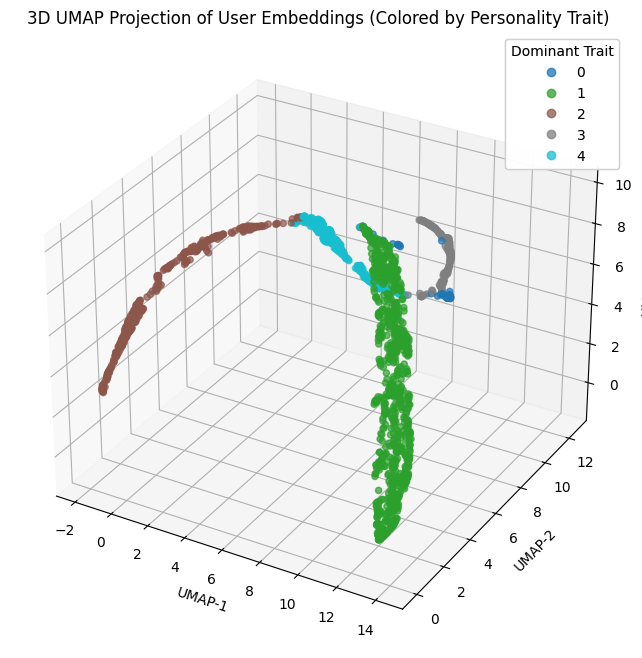

In [60]:
import umap
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D

# Step 1: Put model in eval mode and get embeddings
model.eval()
with torch.no_grad():
    x_dict = {
        "user": model.user_emb(data["user"].node_id) + model.user_lin(data["user"].x),
        "movie": model.movie_emb(data["movie"].node_id),
    }
    final_x_dict = model.gnn(x_dict, data.edge_index_dict)
    user_embeddings = final_x_dict["user"].cpu().numpy()

# Step 2: Reduce to 3D using UMAP
reducer = umap.UMAP(n_neighbors=15, min_dist=0.1, n_components=3, random_state=42)
user_embeddings_3d = reducer.fit_transform(user_embeddings)

# Step 3: (Optional) Color by dominant personality trait
trait_cols = ['openness', 'agreeableness', 'emotional_stability',
              'conscientiousness', 'extraversion']
personality_df = pd.DataFrame(data["user"].x.cpu().numpy(), columns=trait_cols)
personality_df["dominant_trait"] = personality_df[trait_cols].idxmax(axis=1)

# Step 4: 3D Plot
fig = plt.figure(figsize=(10, 8))
ax = fig.add_subplot(111, projection='3d')

scatter = ax.scatter(
    user_embeddings_3d[:, 0],
    user_embeddings_3d[:, 1],
    user_embeddings_3d[:, 2],
    c=pd.factorize(personality_df["dominant_trait"])[0],
    cmap="tab10",
    alpha=0.7
)

ax.set_title("3D UMAP Projection of User Embeddings (Colored by Personality Trait)")
ax.set_xlabel("UMAP-1")
ax.set_ylabel("UMAP-2")
ax.set_zlabel("UMAP-3")

# Add legend
legend1 = ax.legend(*scatter.legend_elements(), title="Dominant Trait")
ax.add_artist(legend1)

plt.show()


/usr/local/lib/python3.11/dist-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


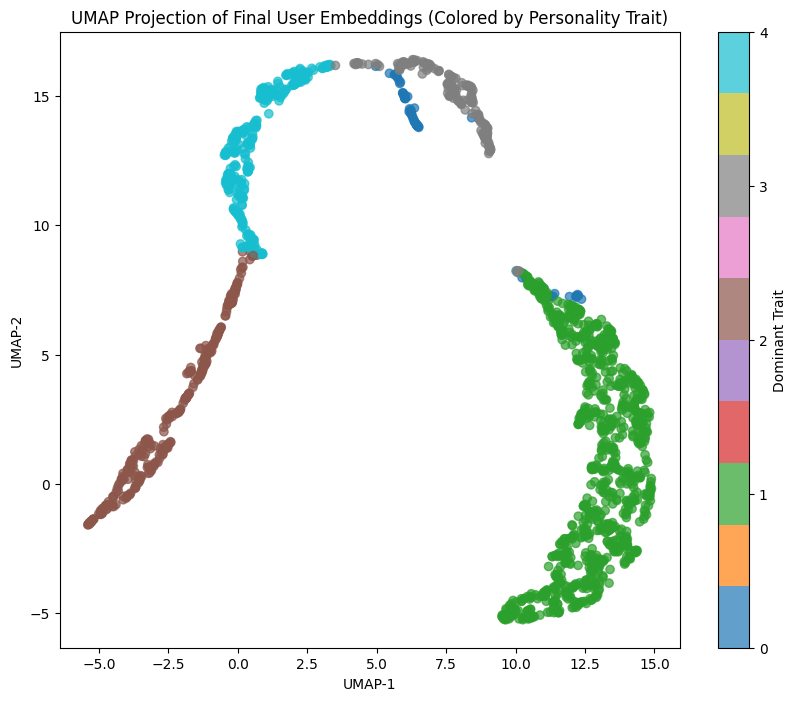

In [59]:
import umap
import matplotlib.pyplot as plt

# Step 1: Put model in eval mode
model.eval()
with torch.no_grad():
    # Forward pass through embedding + GNN layers
    x_dict = {
        "user": model.user_emb(data["user"].node_id) + model.user_lin(data["user"].x),
        "movie": model.movie_emb(data["movie"].node_id),
    }
    final_x_dict = model.gnn(x_dict, data.edge_index_dict)

    # Extract final user embeddings
    user_embeddings = final_x_dict["user"].cpu().numpy()

# Step 2: Reduce to 2D using UMAP
reducer = umap.UMAP(n_neighbors=15, min_dist=0.1, random_state=42)
user_embeddings_2d = reducer.fit_transform(user_embeddings)

# Step 3: (Optional) Color by dominant personality trait
trait_cols = ['openness', 'agreeableness', 'emotional_stability',
              'conscientiousness', 'extraversion']
personality_df = pd.DataFrame(data["user"].x.cpu().numpy(), columns=trait_cols)
personality_df["dominant_trait"] = personality_df[trait_cols].idxmax(axis=1)

# Step 4: Plot
plt.figure(figsize=(10, 8))
scatter = plt.scatter(
    user_embeddings_2d[:, 0],
    user_embeddings_2d[:, 1],
    c=pd.factorize(personality_df["dominant_trait"])[0],
    cmap="tab10",
    alpha=0.7
)
plt.colorbar(scatter, ticks=range(len(trait_cols)), label="Dominant Trait")
plt.title("UMAP Projection of Final User Embeddings (Colored by Personality Trait)")
plt.xlabel("UMAP-1")
plt.ylabel("UMAP-2")
plt.show()


In [14]:
import random, numpy as np, torch
def set_seed(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed(seed)
        torch.backends.cudnn.deterministic = True
        torch.backends.cudnn.benchmark = False

In [35]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Device: '{device}'")

optimizer = torch.optim.Adam(model.parameters(), lr=0.001)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer, mode="max", factor=0.5, patience=2
)

best_val_auc = 0
patience, patience_counter = 2, 0
best_model_state = None

for epoch in range(1, 31):  
    model.train()
    total_loss = total_examples = 0
    for sampled_data in tqdm.tqdm(train_loader):
        optimizer.zero_grad()
        sampled_data = sampled_data.to(device)

        pred = model(sampled_data)
        ground_truth = sampled_data["user", "rates", "movie"].edge_label.float()

        loss = F.binary_cross_entropy_with_logits(pred, ground_truth)
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)  
        optimizer.step()

        total_loss += float(loss) * pred.numel()
        total_examples += pred.numel()

    print(f"Epoch {epoch:03d} | Train Loss: {total_loss / total_examples:.4f}")


    model.eval()
    preds, truths = [], []
    with torch.no_grad():
        for sampled_data in val_loader:
            sampled_data = sampled_data.to(device)
            preds.append(model(sampled_data))
            truths.append(sampled_data["user", "rates", "movie"].edge_label)

    pred = torch.cat(preds, dim=0).cpu().numpy()
    truth = torch.cat(truths, dim=0).cpu().numpy()
    val_auc = roc_auc_score(truth, pred)

    print(f"Epoch {epoch:03d} | Val AUC: {val_auc:.4f}")

    scheduler.step(val_auc)

    if val_auc > best_val_auc:
        best_val_auc = val_auc
        best_model_state = {k: v.cpu() for k, v in model.state_dict().items()}
        patience_counter = 0
    else:
        patience_counter += 1
        if patience_counter >= patience:
            print("Early stopping.")
            break

Device: 'cuda'


  0%|          | 0/1929 [00:00<?, ?it/s]


RuntimeError: Expected all tensors to be on the same device, but found at least two devices, cpu and cuda:0! (when checking argument for argument index in method wrapper_CUDA__index_select)

In [41]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Device: '{device}'")
model = model.to(device)
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)
for epoch in range(1, 3):
    total_loss = total_examples = 0
    for sampled_data in tqdm.tqdm(train_loader):
        optimizer.zero_grad()
        sampled_data.to(device)
        pred = model(sampled_data)
        ground_truth = sampled_data["user", "rates", "movie"].edge_label
        loss = F.binary_cross_entropy_with_logits(pred, ground_truth)
        loss.backward()
        optimizer.step()
        total_loss += float(loss) * pred.numel()
        total_examples += pred.numel()
    print(f"Epoch: {epoch:03d}, Loss: {total_loss / total_examples:.4f}")

Device: 'cuda'


100%|██████████| 1929/1929 [00:22<00:00, 87.32it/s]


Epoch: 001, Loss: 0.2512


100%|██████████| 1929/1929 [00:21<00:00, 90.12it/s]

Epoch: 002, Loss: 0.2483


In [42]:
# preds = []
# ground_truths = []
# for sampled_data in tqdm.tqdm(val_loader):
#     with torch.no_grad():
#         sampled_data.to(device)
#         preds.append(model(sampled_data))
#         ground_truths.append(sampled_data["user", "rates", "movie"].edge_label)
# pred = torch.cat(preds, dim=0).cpu().numpy()
# ground_truth = torch.cat(ground_truths, dim=0).cpu().numpy()
# auc = roc_auc_score(ground_truth, pred)
# print()
# print(f"Validation AUC: {auc:.4f}")

preds = []
ground_truths = []
for sampled_data in tqdm.tqdm(test_loader):
    with torch.no_grad():
        sampled_data.to(device)
        preds.append(model(sampled_data))
        ground_truths.append(sampled_data["user", "rates", "movie"].edge_label)
pred = torch.cat(preds, dim=0).cpu().numpy()
ground_truth = torch.cat(ground_truths, dim=0).cpu().numpy()
auc = roc_auc_score(ground_truth, pred)
print()
print(f"Test AUC: {auc:.4f}")

100%|██████████| 804/804 [00:06<00:00, 132.46it/s]



Test AUC: 0.8943


In [38]:
# Set your desired N value
N = [3, 5, 10]

preds = []
ground_truths = []
users_list = []

# Validation loop
for sampled_data in tqdm.tqdm(val_loader):
    with torch.no_grad():
        sampled_data.to(device)
        # Get predictions
        batch_pred = model(sampled_data)
        # Get edge labels and user indices
        edge_label = sampled_data["user", "rates", "movie"].edge_label
        edge_label_index = sampled_data["user", "rates", "movie"].edge_label_index
        batch_users = edge_label_index[0]  # Extract user indices
        
        # Store results
        preds.append(batch_pred.cpu())
        ground_truths.append(edge_label.cpu())
        users_list.append(batch_users.cpu())

# Concatenate all batches
pred = torch.cat(preds, dim=0).numpy()
ground_truth = torch.cat(ground_truths, dim=0).numpy()
users = torch.cat(users_list, dim=0).numpy()

# Group predictions and labels by user
user_data = defaultdict(lambda: {'preds': [], 'labels': []})
for user, p, lbl in zip(users, pred, ground_truth):
    user_data[user]['preds'].append(p)
    user_data[user]['labels'].append(lbl)

# Calculate metrics
for num in N:
    hr_scores = []
    ndcg_scores = []
    
    for user, data in user_data.items():
        preds_user = np.array(data['preds'])
        labels_user = np.array(data['labels'])
        
        # Sort by predicted score descending
        sort_idx = np.argsort(preds_user)[::-1]
        sorted_labels = labels_user[sort_idx]
        
        # Hit Rate @N
        hr = 1.0 if np.sum(sorted_labels[:num]) > 0 else 0.0
        hr_scores.append(hr)
        
        # NDCG @N
        dcg = 0.0
        for i, rel in enumerate(sorted_labels[:num]):
            dcg += rel / np.log2(i + 2)  # i starts from 0, position is i+1
        
        ideal_labels = np.sort(labels_user)[::-1]
        idcg = 0.0
        for i, rel in enumerate(ideal_labels[:num]):
            idcg += rel / np.log2(i + 2)
        
        ndcg = dcg / idcg if idcg > 0 else 0.0
        ndcg_scores.append(ndcg)
    
    # Calculate averages
    avg_hr = np.mean(hr_scores)
    avg_ndcg = np.mean(ndcg_scores)
    
    print(f"Validation HR@{num}: {avg_hr:.4f}")
    print(f"Validation NDCG@{num}: {avg_ndcg:.4f}")

100%|██████████| 804/804 [00:06<00:00, 123.06it/s]


Validation HR@3: 0.8892
Validation NDCG@3: 0.8120
Validation HR@5: 0.8920
Validation NDCG@5: 0.8271
Validation HR@10: 0.8947
Validation NDCG@10: 0.8390


In [43]:
# Set your desired N value
N = [3, 5, 10]

preds = []
ground_truths = []
users_list = []

# Validation loop
for sampled_data in tqdm.tqdm(test_loader):
    with torch.no_grad():
        sampled_data.to(device)
        # Get predictions
        batch_pred = model(sampled_data)
        # Get edge labels and user indices
        edge_label = sampled_data["user", "rates", "movie"].edge_label
        edge_label_index = sampled_data["user", "rates", "movie"].edge_label_index
        batch_users = edge_label_index[0]  # Extract user indices
        
        # Store results
        preds.append(batch_pred.cpu())
        ground_truths.append(edge_label.cpu())
        users_list.append(batch_users.cpu())

# Concatenate all batches
pred = torch.cat(preds, dim=0).numpy()
ground_truth = torch.cat(ground_truths, dim=0).numpy()
users = torch.cat(users_list, dim=0).numpy()

# Group predictions and labels by user
user_data = defaultdict(lambda: {'preds': [], 'labels': []})
for user, p, lbl in zip(users, pred, ground_truth):
    user_data[user]['preds'].append(p)
    user_data[user]['labels'].append(lbl)

# Calculate metrics
for num in N:
    hr_scores = []
    ndcg_scores = []
    
    for user, data in user_data.items():
        preds_user = np.array(data['preds'])
        labels_user = np.array(data['labels'])
        
        # Sort by predicted score descending
        sort_idx = np.argsort(preds_user)[::-1]
        sorted_labels = labels_user[sort_idx]
        
        # Hit Rate @N
        hr = 1.0 if np.sum(sorted_labels[:num]) > 0 else 0.0
        hr_scores.append(hr)
        
        # NDCG @N
        dcg = 0.0
        for i, rel in enumerate(sorted_labels[:num]):
            dcg += rel / np.log2(i + 2)  # i starts from 0, position is i+1
        
        ideal_labels = np.sort(labels_user)[::-1]
        idcg = 0.0
        for i, rel in enumerate(ideal_labels[:num]):
            idcg += rel / np.log2(i + 2)
        
        ndcg = dcg / idcg if idcg > 0 else 0.0
        ndcg_scores.append(ndcg)
    
    # Calculate averages
    avg_hr = np.mean(hr_scores)
    avg_ndcg = np.mean(ndcg_scores)
    
    print(f"Test HR@{num}: {avg_hr:.4f}")
    print(f"Test NDCG@{num}: {avg_ndcg:.4f}")

100%|██████████| 804/804 [00:06<00:00, 127.29it/s]


Test HR@3: 0.8646
Test NDCG@3: 0.6984
Test HR@5: 0.8757
Test NDCG@5: 0.7274
Test HR@10: 0.8785
Test NDCG@10: 0.7458


In [34]:
import torch.nn.functional as F

device = next(model.parameters()).device
model.eval()

with torch.no_grad():
    x_user = model.user_emb(data_full["user"].node_id.to(device)) \
             + model.user_lin(data_full["user"].x.to(device))
    x_movie = model.movie_emb(data_full["movie"].node_id.to(device))

    x_dict = model.gnn(
        {"user": x_user, "movie": x_movie},
        data_full.edge_index_dict
    )
    user_emb = x_dict["user"]    # shape [num_users, H]
    movie_emb = x_dict["movie"]  # shape [num_movies, H]

# Normalize to compute cosine similarity
user_emb = F.normalize(user_emb, dim=1)
movie_emb = F.normalize(movie_emb, dim=1)

# Cosine similarity = dot product between normalized embeddings
batch_size = 128
k = 50
edges = []

num_users = user_emb.size(0)
all_movie_emb_t = movie_emb.t()  # [H, num_movies]

for start in range(0, num_users, batch_size):
    end = min(start + batch_size, num_users)
    u_batch = user_emb[start:end]           # [B, H]
    sims = u_batch @ all_movie_emb_t        # [B, num_movies], cosine similarities

    # For each user in this batch, get their top-k movies
    top_k_scores, top_k_indices = torch.topk(sims, k, dim=1)
    
    # Convert to global user indices and collect edges
    for i, user_idx in enumerate(range(start, end)):
        for j in range(k):
            movie_idx = top_k_indices[i, j].item()
            score = top_k_scores[i, j].item()
            edges.append((user_idx, movie_idx, score))

print(f"Generated {len(edges)} edges with top-{k} approach")

NameError: name 'data_full' is not defined

In [24]:
print('no of edges in old graph: ', len(edge_index_user_to_movie[1]))
print('no of edges in new graph: ', len(edges))

no of edges in old graph:  1028751
no of edges in new graph:  457199


In [25]:
import torch
import torch.nn.functional as F
import numpy as np
import networkx as nx
from infomap import Infomap
from networkx.algorithms.community import modularity
import pandas as pd
from tqdm import tqdm

def get_model_embeddings(model, data_full, device):
    """
    Extract normalized user and movie embeddings from your trained model.
    This creates the foundation for all our alternative approaches.
    """
    model.eval()
    with torch.no_grad():
        # Get user embeddings (combining learned embeddings with personality features)
        x_user = model.user_emb(data_full["user"].node_id.to(device)) \
                 + model.user_lin(data_full["user"].x.to(device))
        x_movie = model.movie_emb(data_full["movie"].node_id.to(device))
        
        # Pass through the GNN to get final representations
        x_dict = model.gnn(
            {"user": x_user, "movie": x_movie},
            data_full.edge_index_dict
        )
        user_emb = x_dict["user"]    # shape [num_users, H]
        movie_emb = x_dict["movie"]  # shape [num_movies, H]
    
    # Normalize embeddings for cosine similarity calculations
    user_emb = F.normalize(user_emb, dim=1)
    movie_emb = F.normalize(movie_emb, dim=1)
    
    return user_emb, movie_emb

def approach_1_top_k_per_user(user_emb, movie_emb, k=20, batch_size=128):
    """
    Approach 1: Top-K recommendations per user
    
    Instead of using a global threshold, we keep only the top-k highest scoring
    movies for each user. This maintains realistic sparsity patterns where each
    user connects to a manageable number of movies.
    
    Think of this like asking: "What are the top 20 movie recommendations for each user?"
    rather than "Which user-movie pairs have similarity above some threshold?"
    """
    print(f"Generating top-{k} recommendations per user...")
    edges = []
    num_users = user_emb.size(0)
    all_movie_emb_t = movie_emb.t()  # [H, num_movies] for efficient computation
    
    for start in tqdm(range(0, num_users, batch_size), desc="Processing users"):
        end = min(start + batch_size, num_users)
        u_batch = user_emb[start:end]           # [B, H]
        sims = u_batch @ all_movie_emb_t        # [B, num_movies], cosine similarities
        
        # For each user in this batch, get their top-k movies
        top_k_scores, top_k_indices = torch.topk(sims, k, dim=1)
        
        # Convert to global user indices and collect edges
        for i, user_idx in enumerate(range(start, end)):
            for j in range(k):
                movie_idx = top_k_indices[i, j].item()
                score = top_k_scores[i, j].item()
                edges.append((user_idx, movie_idx, score))
    
    print(f"Generated {len(edges)} edges with top-{k} approach")
    return edges
def _calculate_quantile_approx(user_emb, movie_emb, percentile, device, batch_size=128, num_bins=10000):
    """
    Calculates an approximate quantile for large-scale similarity scores
    using a histogram to avoid materializing the full similarity matrix.
    This is a memory-efficient alternative to torch.quantile on a huge tensor.
    """
    print(f"Approximating {percentile}-percentile using a histogram with {num_bins} bins...")
    
    # Cosine similarities are in the range [-1, 1]
    min_val, max_val = -1.0, 1.0
    histogram = torch.zeros(num_bins, device=device)
    total_count = 0

    num_users = user_emb.size(0)
    all_movie_emb_t = movie_emb.t()

    for start in tqdm(range(0, num_users, batch_size), desc="Building score histogram"):
        end = min(start + batch_size, num_users)
        u_batch = user_emb[start:end]
        sims = u_batch @ all_movie_emb_t
        
        total_count += sims.numel()

        # Map scores to histogram bins
        bin_indices = ((sims - min_val) / (max_val - min_val) * num_bins).long()
        bin_indices = torch.clamp(bin_indices, 0, num_bins - 1)
        
        # Update histogram with counts from this batch
        counts = torch.bincount(bin_indices.flatten(), minlength=num_bins)
        histogram += counts

    # Calculate the cumulative distribution to find the percentile
    cum_hist = torch.cumsum(histogram, dim=0)
    
    # Find the bin that crosses the percentile threshold
    threshold_count = total_count * (percentile / 100.0)
    
    # .nonzero() returns indices of non-zero elements. We find the first bin
    # where the cumulative count is greater than our target count.
    threshold_bin = (cum_hist >= threshold_count).nonzero(as_tuple=True)[0][0]
    
    # Convert bin index back to a score value
    threshold = min_val + (threshold_bin.item() / num_bins) * (max_val - min_val)
    
    return threshold


def approach_2_percentile_threshold(user_emb, movie_emb, percentile=95, batch_size=128):
    """
    Approach 2: Percentile-based thresholding (MEMORY-EFFICIENT VERSION)
    
    Uses a histogram-based approximation to find the similarity threshold,
    avoiding the creation of a massive tensor with all scores.
    """
    print(f"Computing percentile-based threshold (keeping top {100-percentile}%)...")
    
    # 1. Use the memory-efficient helper to calculate the threshold
    threshold = _calculate_quantile_approx(
        user_emb, movie_emb, percentile, device=user_emb.device, batch_size=batch_size
    )
    print(f"Computed threshold: {threshold:.4f} (approx. top {100-percentile}% of similarities)")
    
    # 2. Second pass: collect edges above the computed threshold
    edges = []
    num_users = user_emb.size(0)
    all_movie_emb_t = movie_emb.t()
    
    for start in tqdm(range(0, num_users, batch_size), desc="Collecting edges"):
        end = min(start + batch_size, num_users)
        u_batch = user_emb[start:end]
        sims = u_batch @ all_movie_emb_t
        
        # Find edges above threshold
        iu, im = (sims > threshold).nonzero(as_tuple=True)
        scores = sims[iu, im]
        iu_global = iu + start
        
        for u_idx, m_idx, s in zip(iu_global.tolist(), im.tolist(), scores.tolist()):
            edges.append((u_idx, m_idx, s))
            
    print(f"Generated {len(edges)} edges with percentile approach")
    return edges

def approach_3_adaptive_threshold_per_user(user_emb, movie_emb, top_percent_per_user=10, batch_size=128):
    """
    Approach 3: Adaptive threshold per user
    
    Each user gets their own threshold based on their personal similarity distribution.
    We keep the top X% of movies for each user, but the actual threshold varies
    per user based on their specific preferences.
    
    This is like saying: "For each user, recommend the movies that are significantly
    better than their average preference, but adapt to each user's pickiness."
    """
    print(f"Using adaptive per-user thresholds (top {top_percent_per_user}% per user)...")
    edges = []
    num_users = user_emb.size(0)
    all_movie_emb_t = movie_emb.t()
    
    for start in tqdm(range(0, num_users, batch_size), desc="Processing users"):
        end = min(start + batch_size, num_users)
        u_batch = user_emb[start:end]
        sims = u_batch @ all_movie_emb_t  # [B, num_movies]
        
        for i, user_idx in enumerate(range(start, end)):
            user_sims = sims[i]  # [num_movies]
            
            # Compute user-specific threshold
            user_threshold = torch.quantile(user_sims, (100 - top_percent_per_user) / 100.0)
            
            # Keep movies above this user's threshold
            movie_indices = (user_sims > user_threshold).nonzero(as_tuple=True)[0]
            scores = user_sims[movie_indices]
            
            for m_idx, score in zip(movie_indices.tolist(), scores.tolist()):
                edges.append((user_idx, m_idx, score))
    
    print(f"Generated {len(edges)} edges with adaptive threshold approach")
    return edges

def approach_4_original_plus_predicted(original_edges, user_emb, movie_emb, 
                                     enhancement_ratio=0.5, batch_size=128):
    """
    Approach 4: Enhance original graph with selective predictions
    
    Instead of replacing the original graph entirely, we keep all original edges
    and add a carefully selected subset of predicted edges. This preserves the
    original community structure while enriching it with model insights.
    
    Think of this as: "Keep all the ratings we know about, but add some high-confidence
    predictions to fill in gaps."
    """
    print(f"Enhancing original graph with {enhancement_ratio*100}% additional edges...")
    
    # Convert original edges to a set for fast lookup
    original_edge_set = set()
    u_orig, m_orig = original_edges[0].tolist(), original_edges[1].tolist()
    for u, m in zip(u_orig, m_orig):
        original_edge_set.add((u, m))
    
    print(f"Original graph has {len(original_edge_set)} edges")
    
    # Generate predictions for all possible edges
    all_predictions = []
    num_users = user_emb.size(0)
    all_movie_emb_t = movie_emb.t()
    
    for start in tqdm(range(0, num_users, batch_size), desc="Computing predictions"):
        end = min(start + batch_size, num_users)
        u_batch = user_emb[start:end]
        sims = u_batch @ all_movie_emb_t
        
        # Only consider edges that don't exist in original graph
        for i, user_idx in enumerate(range(start, end)):
            user_sims = sims[i]
            for movie_idx in range(user_sims.size(0)):
                if (user_idx, movie_idx) not in original_edge_set:
                    score = user_sims[movie_idx].item()
                    all_predictions.append((user_idx, movie_idx, score))
    
    # Sort predictions by score and take top portion
    all_predictions.sort(key=lambda x: x[2], reverse=True)
    num_to_add = int(len(original_edge_set) * enhancement_ratio)
    selected_predictions = all_predictions[:num_to_add]
    
    # Combine original edges with selected predictions
    enhanced_edges = []
    
    # Add original edges (with dummy scores)
    for u, m in zip(u_orig, m_orig):
        enhanced_edges.append((u, m, 1.0))  # Original edges get score 1.0
    
    # Add predicted edges
    enhanced_edges.extend(selected_predictions)
    
    print(f"Enhanced graph has {len(enhanced_edges)} total edges")
    print(f"Added {len(selected_predictions)} predicted edges")
    
    return enhanced_edges

def evaluate_graph_approach(edges, num_users_offset=0):
    """
    Evaluate the community structure of a graph constructed from edges.
    
    The num_users_offset parameter handles the node indexing for the bipartite graph.
    In our setup, movie nodes need to be offset by the number of users to avoid
    index conflicts in the NetworkX graph.
    """
    if not edges:
        return {"error": "No edges provided"}
    
    # Build NetworkX graph
    G = nx.Graph()
    
    # Determine number of users from the edges
    user_indices = [e[0] for e in edges]
    movie_indices = [e[1] for e in edges]
    
    if num_users_offset == 0:
        num_users_offset = max(user_indices) + 1
    
    # Add edges with proper offset for movies
    for u, m, score in edges:
        G.add_edge(u, m + num_users_offset)
    
    # Community detection using Infomap
    im = Infomap()
    for u, v in G.edges():
        im.add_link(u, v)
    im.run()
    
    # Extract community assignments
    communities = {}
    for node in im.nodes:
        communities[node.node_id] = node.module_id
    
    # Group nodes by community
    modules = {}
    for node, module_id in communities.items():
        modules.setdefault(module_id, set()).add(node)
    
    partition = list(modules.values())
    
    mod_score = modularity(G, partition)

    # Print distribution
    print("\nCommunity sizes:")
    for i, community in enumerate(partition):
        print(f"  Community {i+1:>2}: {len(community)} nodes")
    
    # Calculate metrics
    mod_score = modularity(G, partition)
    
    return {
        "num_nodes": G.number_of_nodes(),
        "num_edges": G.number_of_edges(),
        "num_communities": len(partition),
        "modularity": mod_score,
        "avg_comm_size": sum(len(c) for c in partition) / len(partition) if partition else 0,
        "largest_comm_size": max(len(c) for c in partition) if partition else 0,
        "smallest_comm_size": min(len(c) for c in partition) if partition else 0,
    }

def compare_all_approaches(model, data_full, original_edges, device):
    """
    Run all approaches and compare their results.
    This gives you a comprehensive view of how different reconstruction strategies
    affect community structure.
    """
    print("Extracting embeddings from trained model...")
    user_emb, movie_emb = get_model_embeddings(model, data_full, device)
    
    print(f"\nModel has embeddings for {user_emb.size(0)} users and {movie_emb.size(0)} movies")
    
    # Evaluate original graph
    print("\n" + "="*60)
    print("EVALUATING ORIGINAL GRAPH")
    print("="*60)
    u_orig, m_orig = original_edges[0].tolist(), original_edges[1].tolist()
    original_edge_list = [(u, m, 1.0) for u, m in zip(u_orig, m_orig)]
    original_stats = evaluate_graph_approach(original_edge_list)
    
    print("Original Graph Statistics:")
    for k, v in original_stats.items():
        print(f"  {k:20s}: {v}")
    
    # Approach 1: Top-K per user
    print("\n" + "="*60)
    print("APPROACH 1: TOP-K RECOMMENDATIONS PER USER")
    print("="*60)
    edges_topk = approach_1_top_k_per_user(user_emb, movie_emb, k=15)
    stats_topk = evaluate_graph_approach(edges_topk)
    
    print("Top-K Approach Statistics:")
    for k, v in stats_topk.items():
        print(f"  {k:20s}: {v}")
    
    # Approach 2: Percentile threshold
    print("\n" + "="*60)
    print("APPROACH 2: PERCENTILE-BASED THRESHOLD")
    print("="*60)
    edges_percentile = approach_2_percentile_threshold(user_emb, movie_emb, percentile=99)
    stats_percentile = evaluate_graph_approach(edges_percentile)
    
    print("Percentile Approach Statistics:")
    for k, v in stats_percentile.items():
        print(f"  {k:20s}: {v}")
    
    # Approach 3: Adaptive threshold per user
    print("\n" + "="*60)
    print("APPROACH 3: ADAPTIVE THRESHOLD PER USER")
    print("="*60)
    edges_adaptive = approach_3_adaptive_threshold_per_user(user_emb, movie_emb, top_percent_per_user=5)
    stats_adaptive = evaluate_graph_approach(edges_adaptive)
    
    print("Adaptive Approach Statistics:")
    for k, v in stats_adaptive.items():
        print(f"  {k:20s}: {v}")
    
    # Approach 4: Enhanced original graph
    print("\n" + "="*60)
    print("APPROACH 4: ENHANCED ORIGINAL GRAPH")
    print("="*60)
    edges_enhanced = approach_4_original_plus_predicted(original_edges, user_emb, movie_emb, 
                                                       enhancement_ratio=0.3)
    stats_enhanced = evaluate_graph_approach(edges_enhanced)
    
    print("Enhanced Graph Statistics:")
    for k, v in stats_enhanced.items():
        print(f"  {k:20s}: {v}")
    
    # Summary comparison
    print("\n" + "="*60)
    print("SUMMARY COMPARISON")
    print("="*60)
    
    approaches = {
        "Original": original_stats,
        "Top-K": stats_topk,
        "Percentile": stats_percentile,
        "Adaptive": stats_adaptive,
        "Enhanced": stats_enhanced
    }
    
    print(f"{'Approach':<12} {'Nodes':<8} {'Edges':<10} {'Communities':<12} {'Modularity':<12}")
    print("-" * 60)
    
    for name, stats in approaches.items():
        if 'error' not in stats:
            print(f"{name:<12} {stats['num_nodes']:<8} {stats['num_edges']:<10} "
                  f"{stats['num_communities']:<12} {stats['modularity']:<12.4f}")
    
    return approaches

# Example usage with your existing code:
results = compare_all_approaches(model, data_full, edge_index_user_to_movie, device)

Extracting embeddings from trained model...


AttributeError: 'Model' object has no attribute 'user_lin'